# Tema 2 - ML aplicat 

In [1]:
# fisiere existente:
# heart_4_test.csv
# heart_4_train.csv
# heart_full.csv
# pirvision_office_test.csv
# pirvision_office_train.csv
# pirvision_full.csv
# tema.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from scipy.stats import chi2_contingency

## Incarcare setul de date

Train shape: (3392, 19)
Test shape: (848, 19)
Full shape: (4240, 19)
Columns: ['blood_pressure_medication', 'cholesterol_level', 'stroke_history', 'systolic_pressure', 'hypertension_history', 'daily_cigarettes', 'diastolic_pressure', 'heart_rate', 'smoking_status', 'diabetes_history', 'mass_index', 'blood_sugar_level', 'age', 'education_level', 'gender', 'sleep_heart_rate', 'ldl_cholesterol', 'high_blood_sugar', 'chd_risk']

Tipuri de atribute:
Continuous: ['cholesterol_level', 'systolic_pressure', 'daily_cigarettes', 'diastolic_pressure', 'heart_rate', 'mass_index', 'blood_sugar_level', 'age', 'sleep_heart_rate', 'ldl_cholesterol']
Discrete: ['education_level']
Ordinal: ['blood_pressure_medication', 'stroke_history', 'hypertension_history', 'smoking_status', 'diabetes_history', 'gender', 'high_blood_sugar']
Target: chd_risk

Valori lipsă în train:
                           missing_count  missing_pct
blood_pressure_medication             44     1.297170
cholesterol_level              

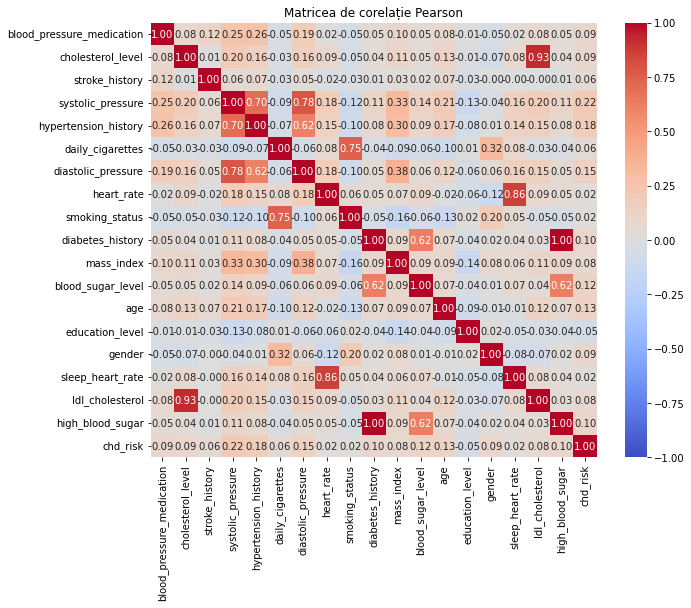


Corelații semnificative categorice (Chi²):
stroke_history <--> hypertension_history (p=0.0001)
stroke_history <--> chd_risk (p=0.0000)
hypertension_history <--> diabetes_history (p=0.0000)
hypertension_history <--> high_blood_sugar (p=0.0000)
hypertension_history <--> chd_risk (p=0.0000)
diabetes_history <--> high_blood_sugar (p=0.0000)
diabetes_history <--> chd_risk (p=0.0000)
gender <--> chd_risk (p=0.0000)
high_blood_sugar <--> chd_risk (p=0.0000)


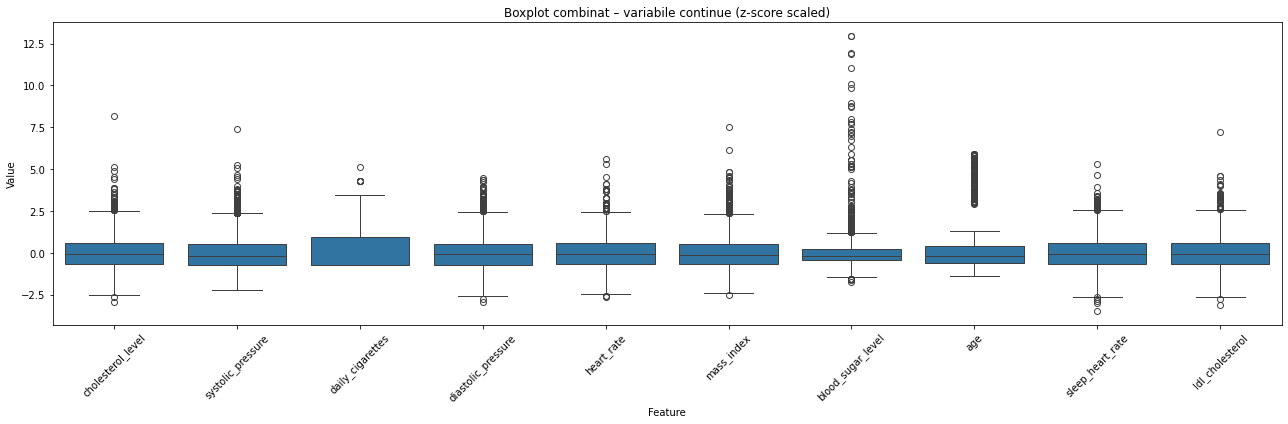

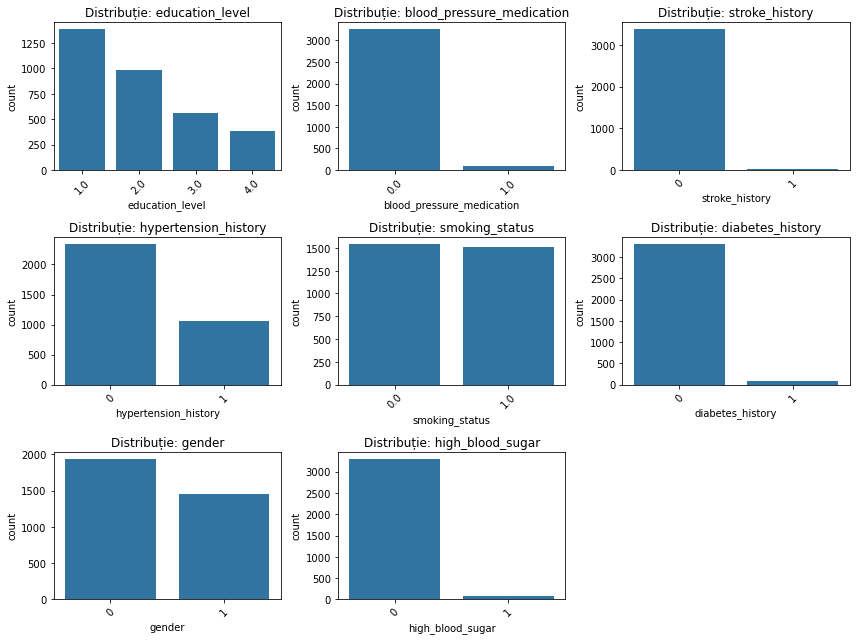

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import math

# === 1. Citirea corectă a datelor ===
# Explicităm parametrii necesari pentru NaN handling
na_values = ["", " ", "NA", "NaN", "nan", "?"]
df_train = pd.read_csv('heart_4_train.csv', na_values=na_values)
df_test  = pd.read_csv('heart_4_test.csv', na_values=na_values)
df_full  = pd.concat([df_train, df_test], ignore_index=True)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Full shape:", df_full.shape)
print("Columns:", df_train.columns.tolist())

# === 2. Exploratory Data Analysis (EDA) ===
target_column = 'chd_risk'

# 2.1 Detectare tipuri de atribute
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_column]

continuous_features = [c for c in num_cols if df_train[c].nunique() > 15]
discrete_features   = [c for c in num_cols if 2 < df_train[c].nunique() <= 15]
ordinal_features    = [c for c in num_cols if df_train[c].nunique() == 2]

print("\nTipuri de atribute:")
print("Continuous:", continuous_features)
print("Discrete:", discrete_features)
print("Ordinal:", ordinal_features)
print("Target:", target_column)

# 2.2 Valori lipsă
missing = df_train.isna().sum().to_frame('missing_count')
missing['missing_pct'] = 100 * missing['missing_count'] / len(df_train)
print("\nValori lipsă în train:")
print(missing)

# 2.3 Outlieri (IQR)
Q1 = df_full.quantile(0.25)
Q3 = df_full.quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (df_full < (Q1 - 1.5 * IQR)) | (df_full > (Q3 + 1.5 * IQR))
outlier_counts = outlier_condition.sum()

outliers_df = pd.DataFrame({
    'outlier_count': outlier_counts,
    'outlier_pct': 100 * outlier_counts / len(df_full)
})
print("\nOutlieri detectați (full):")
print(outliers_df)
print(f"Total outlieri în dataset: {outlier_condition.sum().sum()}")

# 2.4 Statistici descriptive pentru atribute continue
desc = df_train[continuous_features].describe().T.rename(
    columns={'count':'non_missing','std':'std_dev','25%':'p25','50%':'median','75%':'p75'}
)
print("\nStatistici descriptive continue:")
print(desc)

# 2.5 Statistici pentru atribute discrete și ordinale
disc = df_train[discrete_features + ordinal_features].agg(['count', 'nunique']).T.rename(
    columns={'count': 'non_missing', 'nunique': 'unique_vals'}
)
print("\nStatistici discrete/ordinale:")
print(disc)


# 2.8 Corelații numerice
corr = df_full.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matricea de corelație Pearson')
plt.show()

# 2.9 Corelații categorice (Chi-square)
discrete_cols = df_train.select_dtypes(include=['object', 'category', 'int']).columns.tolist()
print("\nCorelații semnificative categorice (Chi²):")
for i, col1 in enumerate(discrete_cols):
    for col2 in discrete_cols[i+1:]:
        tbl = pd.crosstab(df_train[col1], df_train[col2])
        if tbl.size > 1:
            chi2, p, _, _ = chi2_contingency(tbl)
            if p < 0.05:
                print(f"{col1} <--> {col2} (p={p:.4f})")

# 2.10 Vizualizare Boxplot combinat
df_norm = df_train[continuous_features].apply(lambda x: (x - x.mean()) / x.std())
df_long = pd.melt(df_norm, var_name='Feature', value_name='Value')

plt.figure(figsize=(18, 6))
sns.boxplot(data=df_long, x='Feature', y='Value', showfliers=True)
plt.title("Boxplot combinat – variabile continue (z-score scaled)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2.11 Countplot-uri pe categorice/ordinale
cat_feats = discrete_features + ordinal_features
cols = 3
rows = math.ceil(len(cat_feats) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = axes.flatten()

for ax, col in zip(axes, cat_feats):
    sns.countplot(x=col, data=df_train, ax=ax)
    ax.set_title(f'Distribuție: {col}')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_feats):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()





## Check validity


In [3]:
continuous_features = [c for c in continuous_features if c in df_train.columns]
discrete_features = [c for c in discrete_features if c in df_train.columns]
ordinal_features = [c for c in ordinal_features if c in df_train.columns]
# Asigură-te că target_column este valid
if target_column in df_train.columns:
    print(f"Target column '{target_column}' is valid.")
else:
    print(f"Warning: Target column '{target_column}' not found in training data. Please check the column name.")

Target column 'chd_risk' is valid.


## Preprocesarea datelor

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# === 3.1 Înlocuire valori extreme (outlieri) cu NaN ===
for col in continuous_features:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_train[col] = df_train[col].mask((df_train[col] < lower) | (df_train[col] > upper))
    df_test[col]  = df_test[col].mask((df_test[col]  < lower) | (df_test[col]  > upper))

# === 3.2 Imputare + standardizare + encoding ===

# Imputeri
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Pipeline pentru variabile numerice
numeric_pipeline = Pipeline([
    ('imputer', num_imputer),
    ('scaler', StandardScaler())
])

# Pipeline pentru variabile categorice
categorical_pipeline = Pipeline([
    ('imputer', cat_imputer),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer care aplică pachetele
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, continuous_features),
    ('cat', categorical_pipeline, discrete_features + ordinal_features)
])

# === 3.2 Separare X/y și aplicare ===
X_train = df_train.drop(columns=[target_column])
y_train = df_train[target_column]
X_test  = df_test.drop(columns=[target_column])
y_test  = df_test[target_column]

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print("Preprocesare finalizată:")
print("X_train_prep shape:", X_train_prep.shape)
print("X_test_prep shape:", X_test_prep.shape)

# === 3.3 Eliminare atribute numerice redundante ===
# Calcul corelații doar pe continue, înainte de one-hot
numeric_data_imputed = preprocessor.named_transformers_['num'].named_steps['imputer'].transform(df_train[continuous_features])
numeric_df = pd.DataFrame(numeric_data_imputed, columns=continuous_features)
corr_matrix = numeric_df.corr()

# Afișare perechi redundante (|corr| >= 0.2)
threshold = 0.2
redundant_pairs = [(i, j) for i in corr_matrix.columns for j in corr_matrix.columns if i < j and abs(corr_matrix.loc[i, j]) >= threshold]

print(f"\nAtribute numerice cu |corelație| ≥ {threshold}:")
for i, j in redundant_pairs:
    print(f"{i} <--> {j}: corr = {corr_matrix.loc[i, j]:.2f}")


Preprocesare finalizată:
X_train_prep shape: (3392, 28)
X_test_prep shape: (848, 28)

Atribute numerice cu |corelație| ≥ 0.2:
cholesterol_level <--> ldl_cholesterol: corr = 0.89
diastolic_pressure <--> systolic_pressure: corr = 0.71
diastolic_pressure <--> mass_index: corr = 0.30
heart_rate <--> sleep_heart_rate: corr = 0.81
mass_index <--> systolic_pressure: corr = 0.26
age <--> cholesterol_level: corr = 0.25
age <--> systolic_pressure: corr = 0.34
age <--> ldl_cholesterol: corr = 0.25


## Utilizarea algoritmilor de Învățare Automată

Distribuție clase înainte de SMOTE: [2877  515]
Distribuție clase după SMOTE: [2877 2877]

=== Decision Tree (SMOTE) ===
Acuratețe: 0.692
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.75      0.81       719
           1       0.20      0.35      0.26       129

    accuracy                           0.69       848
   macro avg       0.53      0.55      0.53       848
weighted avg       0.76      0.69      0.72       848



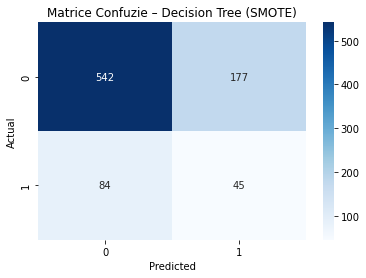


=== Random Forest (SMOTE) ===
Acuratețe: 0.739
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       719
           1       0.26      0.39      0.31       129

    accuracy                           0.74       848
   macro avg       0.57      0.60      0.58       848
weighted avg       0.79      0.74      0.76       848



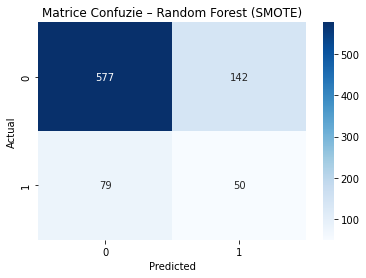


=== Logistic Regression (SMOTE) ===
Acuratețe: 0.659
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.67      0.77       719
           1       0.24      0.59      0.34       129

    accuracy                           0.66       848
   macro avg       0.57      0.63      0.56       848
weighted avg       0.80      0.66      0.71       848



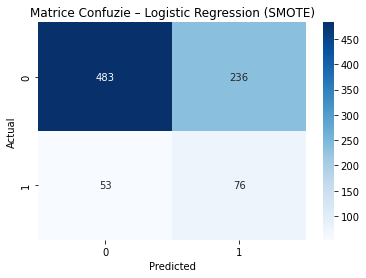


=== MLP (SMOTE) ===
Acuratețe: 0.712
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82       719
           1       0.22      0.36      0.28       129

    accuracy                           0.71       848
   macro avg       0.55      0.57      0.55       848
weighted avg       0.77      0.71      0.74       848



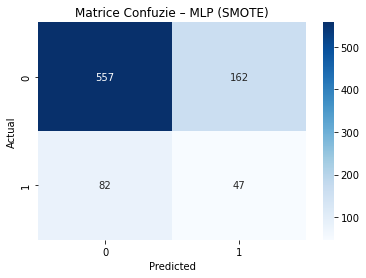

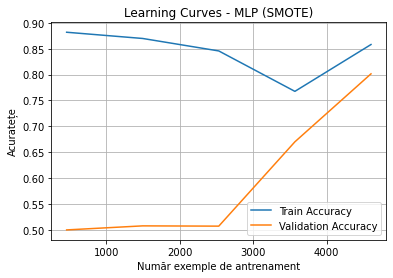


=== Tabel comparativ – Risc Coronarian ===
                 Model  Accuracy  Precision Clasa 1  Recall Clasa 1  \
0        Decision Tree     0.692              0.203           0.349   
1        Random Forest     0.739              0.260           0.388   
2  Logistic Regression     0.659              0.244           0.589   
3                  MLP     0.712              0.225           0.364   

   F1 Clasa 1  Recall Clasa 0  F1 Clasa 0  
0       0.256           0.754       0.806  
1       0.312           0.803       0.839  
2       0.345           0.672       0.770  
3       0.278           0.775       0.820  


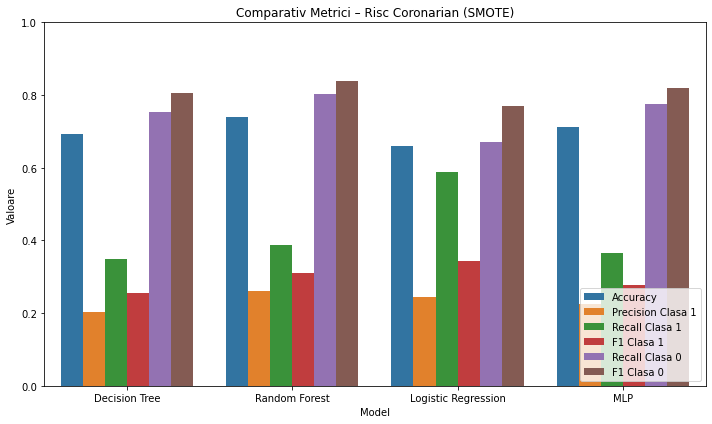

In [ ]:
from sklearn.model_selection import learning_curve
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# === 1. Aplicăm SMOTE doar pe setul de antrenament ===
print("Distribuție clase înainte de SMOTE:", np.bincount(y_train))
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)
print("Distribuție clase după SMOTE:", np.bincount(y_train_bal))

# === 2. Funcție de evaluare ===
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)

    print(f"\n=== {name} ===")
    print(f"Acuratețe: {acc:.3f}")
    print("Classification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matrice Confuzie – {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# === 3. Modele ML ===

# 3.1 Decision Tree
dt = DecisionTreeClassifier(
    max_depth=5,               # adâncime maximă a arborelui
    min_samples_leaf=10,       # minim 10 exemple per frunză
    criterion='gini',          # funcția de impuritate
    class_weight='balanced',   # ponderare automată pe clase
    random_state=42
)
evaluate_model(dt, X_train_bal, y_train_bal, X_test_prep, y_test, 'Decision Tree (SMOTE)')

# 3.2 Random Forest
rf = RandomForestClassifier(
    n_estimators=100,          # număr arbori
    max_depth=7,
    min_samples_leaf=5,
    max_features='sqrt',       # proporția de atribute per arbore
    criterion='gini',
    class_weight='balanced',
    random_state=42
)
evaluate_model(rf, X_train_bal, y_train_bal, X_test_prep, y_test, 'Random Forest (SMOTE)')

# 3.3 Logistic Regression
lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=300,
    class_weight='balanced',
    random_state=42
)
evaluate_model(lr, X_train_bal, y_train_bal, X_test_prep, y_test, 'Logistic Regression (SMOTE)')

# 3.4 MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    random_state=42
)
evaluate_model(mlp, X_train_bal, y_train_bal, X_test_prep, y_test, 'MLP (SMOTE)')

# === 4. Learning Curves pentru MLP ===
train_sizes, train_scores, val_scores = learning_curve(
    mlp, X_train_bal, y_train_bal,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
)
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train Accuracy')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation Accuracy')
plt.xlabel('Număr exemple de antrenament')
plt.ylabel('Acuratețe')
plt.title('Learning Curves - MLP (SMOTE)')
plt.legend()
plt.grid(True)
plt.show()

# === 5. Tabel comparativ ===
results = []
for name, model in [('Decision Tree', dt), ('Random Forest', rf), ('Logistic Regression', lr), ('MLP', mlp)]:
    y_pred = model.predict(X_test_prep)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision Clasa 1': report['1']['precision'],
        'Recall Clasa 1': report['1']['recall'],
        'F1 Clasa 1': report['1']['f1-score'],
        'Recall Clasa 0': report['0']['recall'],
        'F1 Clasa 0': report['0']['f1-score']
    })

results_df = pd.DataFrame(results)
print("\n=== Tabel comparativ – Risc Coronarian ===")
print(results_df.round(3))

# === 6. Vizualizare barplot ===
melt_df = results_df.melt(id_vars='Model', var_name='Metrică', value_name='Valoare')

plt.figure(figsize=(10,6))
sns.barplot(data=melt_df, x='Model', y='Valoare', hue='Metrică')
plt.ylim(0,1)
plt.title('Comparativ Metrici – Risc Coronarian (SMOTE)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Pirvision

Atribute continue: ['OBS_1', 'OBS_2', 'OBS_3', 'OBS_4', 'OBS_5', 'OBS_6', 'OBS_7', 'OBS_8', 'OBS_9', 'OBS_10', 'OBS_11', 'OBS_12', 'OBS_13', 'OBS_14', 'OBS_15', 'OBS_16', 'OBS_17', 'OBS_18', 'OBS_19', 'OBS_20', 'OBS_21', 'OBS_22', 'OBS_23', 'OBS_24', 'OBS_25', 'OBS_26', 'OBS_27', 'OBS_28', 'OBS_29', 'OBS_30', 'OBS_31', 'OBS_32', 'OBS_33', 'OBS_34', 'OBS_35', 'OBS_36', 'OBS_37', 'OBS_38', 'OBS_39', 'OBS_40', 'OBS_41', 'OBS_42', 'OBS_43', 'OBS_44', 'OBS_45', 'OBS_46', 'OBS_47', 'OBS_48', 'OBS_49', 'OBS_50', 'OBS_51', 'OBS_52', 'OBS_53', 'OBS_54', 'OBS_55', 'OBS_56', 'OBS_57']
Atribute discrete: ['Temp (F)']
Atribute ordinale: []

Valori lipsă (train):
            missing_count  missing_pct
Timestamp            788        9.850
Day Index              0        0.000
Day                  790        9.875
Temp (F)               0        0.000
Temp (C)               0        0.000
...                  ...          ...
OBS_54                 0        0.000
OBS_55                 0        0.000

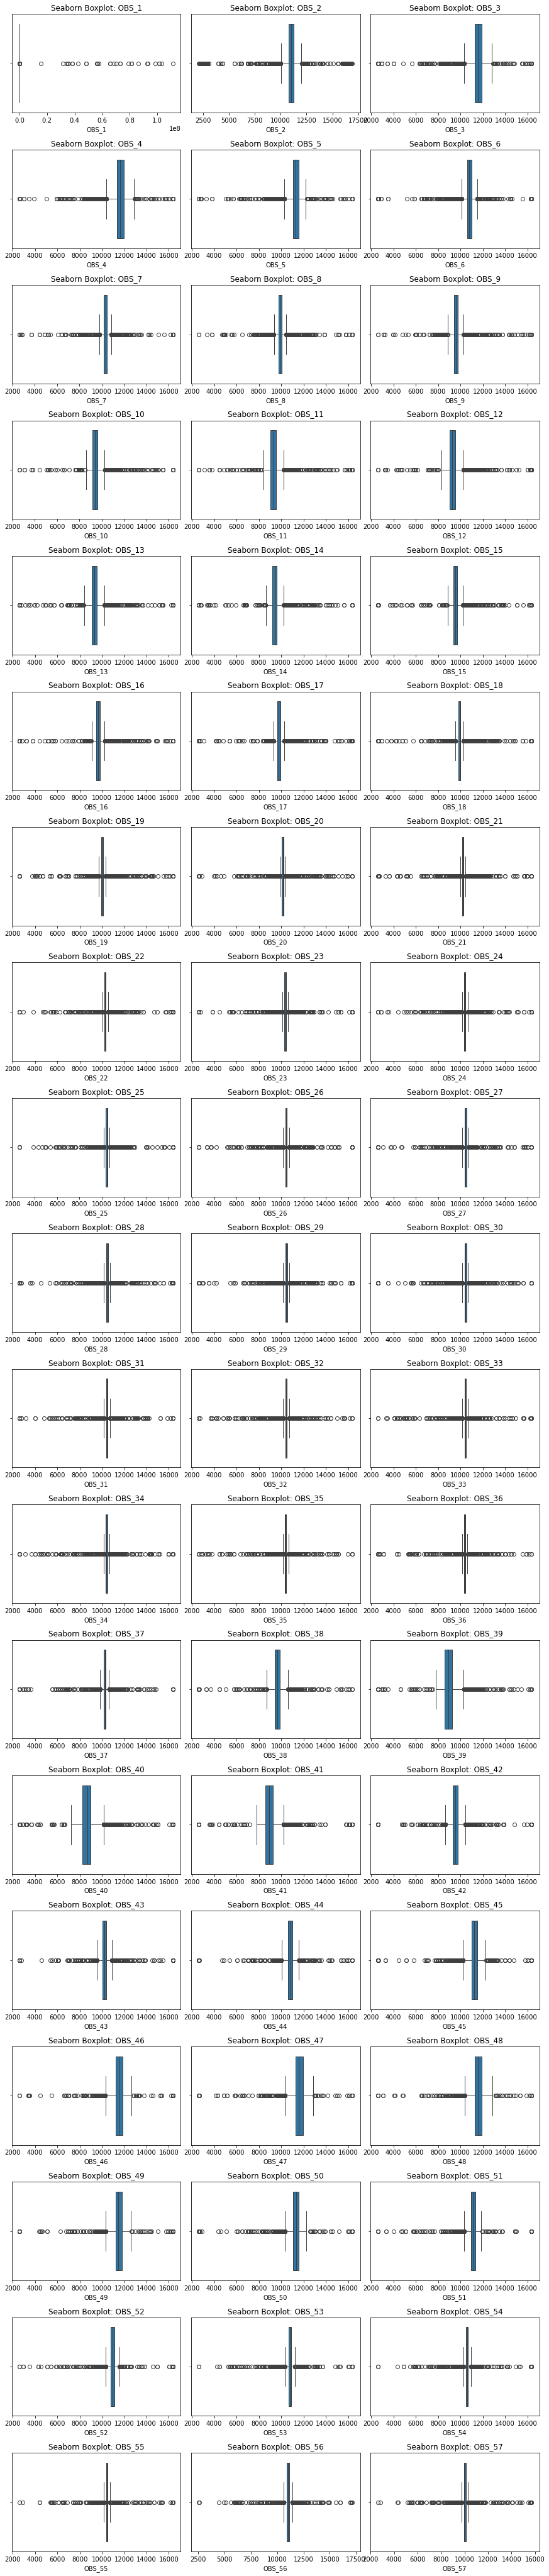

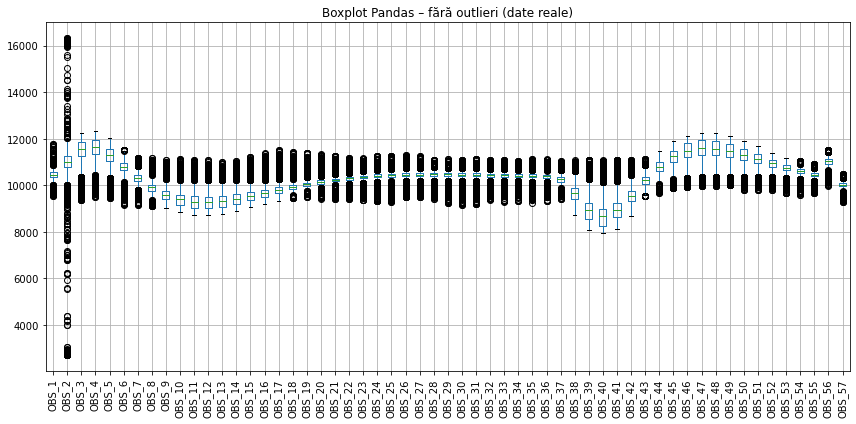

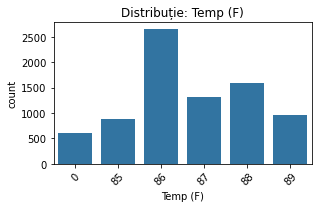

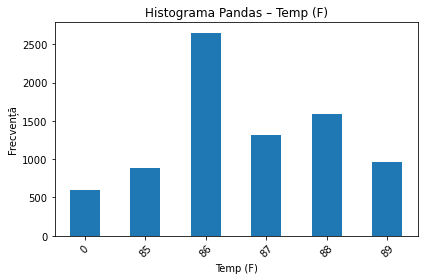


Temp (F) – Valori unice: [86  0 89 87 88 85]


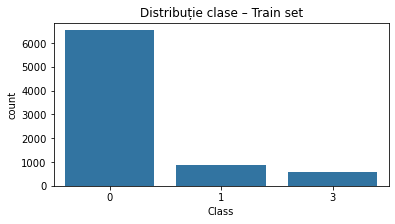

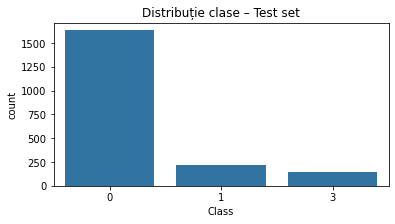


Distribuție clase (Train – procentual):
Class
0    81.6500
1    10.8875
3     7.4625
Name: proportion, dtype: float64


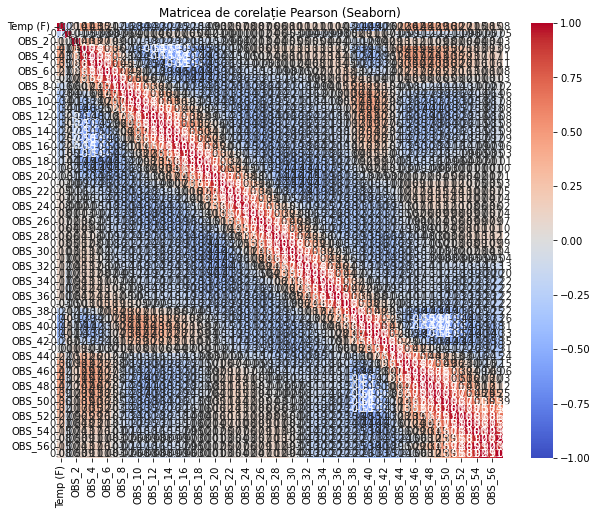

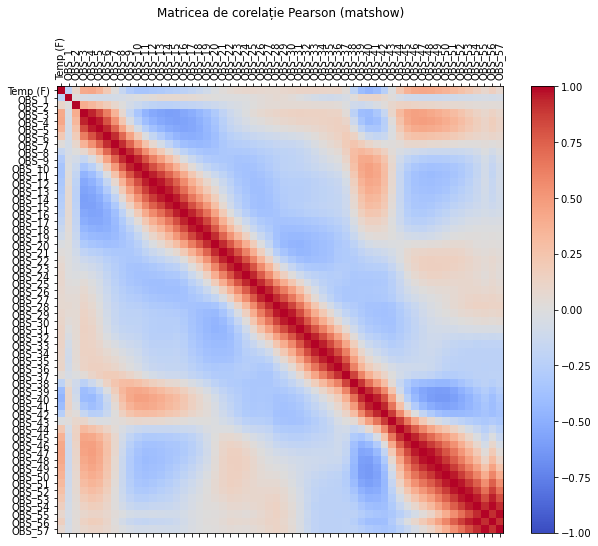


Atribute numeric redundante (|corr| > 0.9):
OBS_3 <--> OBS_4: corr = 0.94
OBS_4 <--> OBS_3: corr = 0.94
OBS_4 <--> OBS_5: corr = 0.95
OBS_5 <--> OBS_4: corr = 0.95
OBS_5 <--> OBS_6: corr = 0.93
OBS_6 <--> OBS_5: corr = 0.93
OBS_6 <--> OBS_7: corr = 0.92
OBS_7 <--> OBS_6: corr = 0.92
OBS_7 <--> OBS_8: corr = 0.92
OBS_8 <--> OBS_7: corr = 0.92
OBS_8 <--> OBS_9: corr = 0.93
OBS_9 <--> OBS_8: corr = 0.93
OBS_9 <--> OBS_10: corr = 0.94
OBS_10 <--> OBS_9: corr = 0.94
OBS_10 <--> OBS_11: corr = 0.94
OBS_11 <--> OBS_10: corr = 0.94
OBS_11 <--> OBS_12: corr = 0.95
OBS_12 <--> OBS_11: corr = 0.95
OBS_12 <--> OBS_13: corr = 0.97
OBS_13 <--> OBS_12: corr = 0.97
OBS_13 <--> OBS_14: corr = 0.96
OBS_14 <--> OBS_13: corr = 0.96
OBS_14 <--> OBS_15: corr = 0.96
OBS_15 <--> OBS_14: corr = 0.96
OBS_15 <--> OBS_16: corr = 0.95
OBS_16 <--> OBS_15: corr = 0.95
OBS_16 <--> OBS_17: corr = 0.94
OBS_17 <--> OBS_16: corr = 0.94
OBS_17 <--> OBS_18: corr = 0.96
OBS_18 <--> OBS_17: corr = 0.96
OBS_18 <--> OBS_19: c

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import math

# 1. Citirea datelor
pir_df_train = pd.read_csv('pirvision_office_train.csv')
pir_df_test = pd.read_csv('pirvision_office_test.csv')
pir_df_full = pd.concat([pir_df_train, pir_df_test], ignore_index=True)

pir_target_column = 'Class'

# 2. Eliminare coloane neinformative
cols_to_exclude = ['Class', 'Day Index', 'Temp (C)']
pir_df_filtered = pir_df_full.drop(columns=[col for col in cols_to_exclude if col in pir_df_full.columns])

# 3. Tipuri de atribute
pir_num_cols = pir_df_filtered.select_dtypes(include=[np.number]).columns.tolist()
pir_continuous_features = [c for c in pir_num_cols if pir_df_filtered[c].nunique() > 15]
pir_discrete_features = [c for c in pir_num_cols if 2 < pir_df_filtered[c].nunique() <= 15]
pir_ordinal_features = [c for c in pir_num_cols if pir_df_filtered[c].nunique() == 2]

print('Atribute continue:', pir_continuous_features)
print('Atribute discrete:', pir_discrete_features)
print('Atribute ordinale:', pir_ordinal_features)

# 4. Valori lipsă
pir_missing = pir_df_train.isna().sum().to_frame('missing_count')
pir_missing['missing_pct'] = 100 * pir_missing['missing_count'] / len(pir_df_train)
print("\nValori lipsă (train):\n", pir_missing)

# 5. Outlieri - IQR
pir_numeric = pir_df_full[pir_num_cols]
pir_Q1 = pir_numeric.quantile(0.25)
pir_Q3 = pir_numeric.quantile(0.75)
pir_IQR = pir_Q3 - pir_Q1
outliers = ((pir_numeric < (pir_Q1 - 1.5 * pir_IQR)) | (pir_numeric > (pir_Q3 + 1.5 * pir_IQR)))
pir_outliers_df = pd.DataFrame({
    'outlier_count': outliers.sum(),
    'outlier_pct': 100 * outliers.sum() / len(pir_df_full)
})
print("\nOutlieri:\n", pir_outliers_df)

# 6. Statistici descriptive - continue
pir_desc = pir_df_train[pir_continuous_features].describe().T.rename(
    columns={'count': 'non_missing', 'std': 'std_dev', '25%': 'p25', '50%': 'median', '75%': 'p75'}
)
print("\nStatistici descriptive pentru atribute continue:\n", pir_desc)

# 7. Statistici - discrete și ordinale
pir_disc = pir_df_train[pir_discrete_features + pir_ordinal_features].agg(['count', 'nunique']).T
pir_disc = pir_disc.rename(columns={'count': 'non_missing', 'nunique': 'unique_vals'})
print("\nStatistici pentru atribute discrete/ordonale:\n", pir_disc)

# 8. Boxplot - seaborn
num_feats = len(pir_continuous_features)
cols = 3
rows = math.ceil(num_feats / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = axes.flatten()
for ax, col in zip(axes, pir_continuous_features):
    sns.boxplot(x=pir_df_train[col], ax=ax)
    ax.set_title(f'Seaborn Boxplot: {col}')
for ax in axes[num_feats:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

# Eliminare outlieri în mod permanent din pir_df_train și pir_df_full
for df in [pir_df_train, pir_df_full]:
    for col in pir_continuous_features:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = np.where((df[col] < lower) | (df[col] > upper), np.nan, df[col])

# Acum putem face boxplot direct pe datele curățate
pir_df_train[pir_continuous_features].boxplot(figsize=(12, 6), rot=90)
plt.title('Boxplot Pandas – fără outlieri (date reale)')
plt.tight_layout()
plt.show()




# 10. Histogramă / countplot – categorice (Seaborn)
cat_feats = pir_discrete_features + pir_ordinal_features
num_feats = len(cat_feats)
cols = 3
rows = math.ceil(num_feats / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = axes.flatten()
for ax, col in zip(axes, cat_feats):
    sns.countplot(x=col, data=pir_df_train, ax=ax)
    ax.set_title(f'Distribuție: {col}')
    ax.tick_params(axis='x', rotation=45)
for ax in axes[num_feats:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

# 11. Histogramă – pandas.hist() + value_counts()
for col in cat_feats:
    pir_df_train[col].value_counts().sort_index().plot(kind='bar', width=0.5)
    plt.title(f'Histograma Pandas – {col}')
    plt.xlabel(col)
    plt.ylabel("Frecvență")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 12. Valori unice - categorice
for col in cat_feats:
    print(f"\n{col} – Valori unice: {pd.unique(pir_df_train[col])}")

# 13. Dezechilibru de clase - countplot
for df, name in [(pir_df_train, 'Train'), (pir_df_test, 'Test')]:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=pir_target_column, data=df)
    plt.title(f'Distribuție clase – {name} set')
    plt.show()

# 14. Dezechilibru de clase – value_counts
print("\nDistribuție clase (Train – procentual):")
print(pir_df_train[pir_target_column].value_counts(normalize=True) * 100)

# 15. Corelații numerice – Pearson
pir_corr = pir_df_filtered[pir_num_cols].corr()

# Heatmap - seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(pir_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matricea de corelație Pearson (Seaborn)')
plt.show()

# Corelație – matshow (cerință explicită)
plt.figure(figsize=(10, 8))
plt.matshow(pir_corr, fignum=1, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(ticks=np.arange(len(pir_corr.columns)), labels=pir_corr.columns, rotation=90)
plt.yticks(ticks=np.arange(len(pir_corr.columns)), labels=pir_corr.columns)
plt.title("Matricea de corelație Pearson (matshow)", pad=20)
plt.show()

# Identificare perechi redundant corelate
strong_corr = pir_corr.abs() > 0.9
redundant_pairs = [(i, j) for i in strong_corr.columns for j in strong_corr.columns
                   if strong_corr.loc[i, j] and i != j]
print("\nAtribute numeric redundante (|corr| > 0.9):")
for i, j in redundant_pairs:
    print(f"{i} <--> {j}: corr = {pir_corr.loc[i, j]:.2f}")

# 16. Corelații categorice – test Chi-Pătrat
pir_discrete_cols = pir_df_train.select_dtypes(include=['object', 'category', 'int']).columns.tolist()
for i, col1 in enumerate(pir_discrete_cols):
    for col2 in pir_discrete_cols[i+1:]:
        tbl = pd.crosstab(pir_df_train[col1], pir_df_train[col2])
        if tbl.size > 1:
            chi2, p, _, _ = chi2_contingency(tbl)
            if p < 0.05:
                print(f"Corelație semnificativă între {col1} și {col2} (p={p:.4f})")


## Preprocesarea Datelor (Preprocessing) pentru Pirvision

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from scipy.stats import chi2_contingency

# 1. Citire date
pir_df_train = pd.read_csv('pirvision_office_train.csv')
pir_df_test = pd.read_csv('pirvision_office_test.csv')
pir_df_full = pd.concat([pir_df_train.copy(), pir_df_test.copy()], ignore_index=True)

pir_target_column = 'Class'

# 2. Eliminare coloane neinformative
cols_to_exclude = ['Class', 'Day Index', 'Temp (C)']
pir_df_filtered = pir_df_full.drop(columns=[col for col in cols_to_exclude if col in pir_df_full.columns])

# 3. Detectare tipuri de atribute
pir_num_cols = pir_df_filtered.select_dtypes(include=[np.number]).columns.tolist()
pir_continuous_features = [c for c in pir_num_cols if pir_df_filtered[c].nunique() > 15]
pir_discrete_features = [c for c in pir_num_cols if 2 < pir_df_filtered[c].nunique() <= 15]
pir_ordinal_features = [c for c in pir_num_cols if pir_df_filtered[c].nunique() == 2]

# 4. Înlocuire outlieri cu NaN în train/test (IQR - standard)
for col in pir_continuous_features:
    Q1 = pir_df_train[col].quantile(0.25)
    Q3 = pir_df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    pir_df_train[col] = pir_df_train[col].mask((pir_df_train[col] < lower) | (pir_df_train[col] > upper))
    pir_df_test[col]  = pir_df_test[col].mask((pir_df_test[col] < lower) | (pir_df_test[col] > upper))


# 5. Imputare + scalare numerică
pir_num_imputer = SimpleImputer(strategy='median')
pir_cat_imputer = SimpleImputer(strategy='most_frequent')

pir_numeric_pipeline = Pipeline([
    ('imputer', pir_num_imputer),
    ('scaler', StandardScaler())
])

# 6. Imputare + codificare categorice
pir_categorical_pipeline = Pipeline([
    ('imputer', pir_cat_imputer),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 7. ColumnTransformer: numerice și categorice
pir_preprocessor = ColumnTransformer(transformers=[
    ('num', pir_numeric_pipeline, pir_continuous_features),
    ('cat', pir_categorical_pipeline, pir_discrete_features + pir_ordinal_features)
])

# 8. Separare X/y
pir_X_train = pir_df_train.drop(columns=[pir_target_column])
pir_y_train = pir_df_train[pir_target_column]
pir_X_test  = pir_df_test.drop(columns=[pir_target_column])
pir_y_test  = pir_df_test[pir_target_column]

# 9. Aplicare preprocesare
pir_X_train_prep = pir_preprocessor.fit_transform(pir_X_train)
pir_X_test_prep  = pir_preprocessor.transform(pir_X_test)

print("Preprocesare completă:")
print("pir_X_train_prep shape:", pir_X_train_prep.shape)
print("pir_X_test_prep shape:", pir_X_test_prep.shape)

# 10. Redundanță - atribute corelate
# Extragem corelația numerică pe datele imputate (scalate invers pentru interpretare)
X_train_imputed = pir_preprocessor.named_transformers_['num'].named_steps['imputer'].transform(
    pir_df_train[pir_continuous_features]
)
X_train_inversed = pd.DataFrame(X_train_imputed, columns=pir_continuous_features)
pir_corr_matrix = X_train_inversed.corr()

# Găsim perechi corelate puternic (|corr| ≥ 0.9)
pir_redundant_pairs = [(i, j) for i in pir_corr_matrix.columns for j in pir_corr_matrix.columns
                       if i < j and abs(pir_corr_matrix.loc[i, j]) >= 0.9]

print("Atribute numerice puternic corelate (|corr| ≥ 0.9):")
for i, j in pir_redundant_pairs:
    print(f"{i} <--> {j}: corr = {pir_corr_matrix.loc[i, j]:.2f}")


Preprocesare completă:
pir_X_train_prep shape: (8000, 63)
pir_X_test_prep shape: (2000, 63)
Atribute numerice puternic corelate (|corr| ≥ 0.9):
OBS_10 <--> OBS_9: corr = 0.91
OBS_10 <--> OBS_11: corr = 0.93
OBS_11 <--> OBS_12: corr = 0.93
OBS_12 <--> OBS_13: corr = 0.95
OBS_13 <--> OBS_14: corr = 0.94
OBS_14 <--> OBS_15: corr = 0.94
OBS_15 <--> OBS_16: corr = 0.92
OBS_40 <--> OBS_47: corr = -0.90
OBS_45 <--> OBS_46: corr = 0.93
OBS_46 <--> OBS_47: corr = 0.94
OBS_47 <--> OBS_48: corr = 0.95
OBS_47 <--> OBS_49: corr = 0.90
OBS_48 <--> OBS_49: corr = 0.95
OBS_49 <--> OBS_50: corr = 0.95
OBS_50 <--> OBS_51: corr = 0.93
OBS_51 <--> OBS_52: corr = 0.92


## Utilizarea algoritmilor de Învățare Automată (Pirvision)

Distribuție clase înainte de SMOTE: [2877  515]
Distribuție clase după SMOTE: [2877 2877]

=== Decision Tree (SMOTE) ===
Acuratețe: 0.692
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.75      0.81       719
           1       0.20      0.35      0.26       129

    accuracy                           0.69       848
   macro avg       0.53      0.55      0.53       848
weighted avg       0.76      0.69      0.72       848



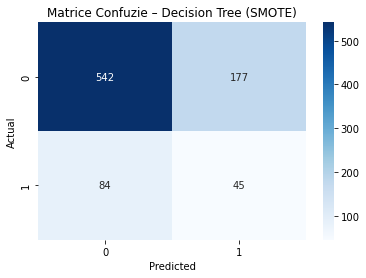


=== Random Forest (SMOTE) ===
Acuratețe: 0.739
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       719
           1       0.26      0.39      0.31       129

    accuracy                           0.74       848
   macro avg       0.57      0.60      0.58       848
weighted avg       0.79      0.74      0.76       848



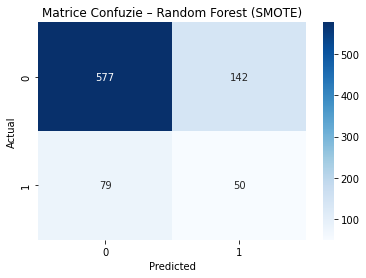


=== Logistic Regression (SMOTE) ===
Acuratețe: 0.659
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.67      0.77       719
           1       0.24      0.59      0.34       129

    accuracy                           0.66       848
   macro avg       0.57      0.63      0.56       848
weighted avg       0.80      0.66      0.71       848



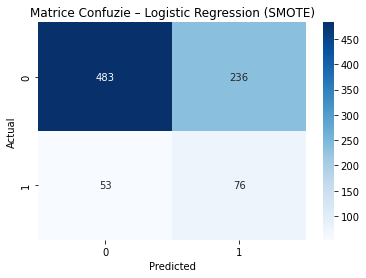


=== MLP (SMOTE) ===
Acuratețe: 0.743
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       719
           1       0.24      0.32      0.27       129

    accuracy                           0.74       848
   macro avg       0.55      0.57      0.56       848
weighted avg       0.77      0.74      0.76       848



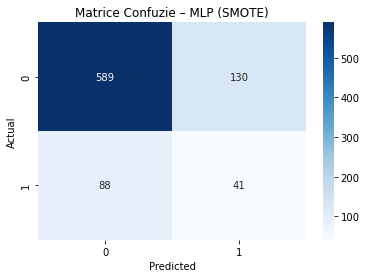

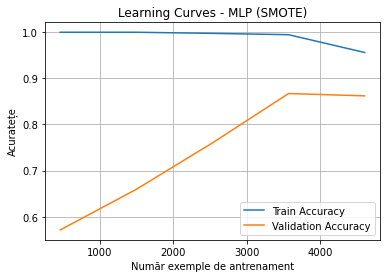


=== Tabel comparativ – Risc Coronarian ===
                 Model  Accuracy  Precision Clasa 1  Recall Clasa 1  \
0        Decision Tree     0.692              0.203           0.349   
1        Random Forest     0.739              0.260           0.388   
2  Logistic Regression     0.659              0.244           0.589   
3                  MLP     0.743              0.240           0.318   

   F1 Clasa 1  Recall Clasa 0  F1 Clasa 0  
0       0.256           0.754       0.806  
1       0.312           0.803       0.839  
2       0.345           0.672       0.770  
3       0.273           0.819       0.844  


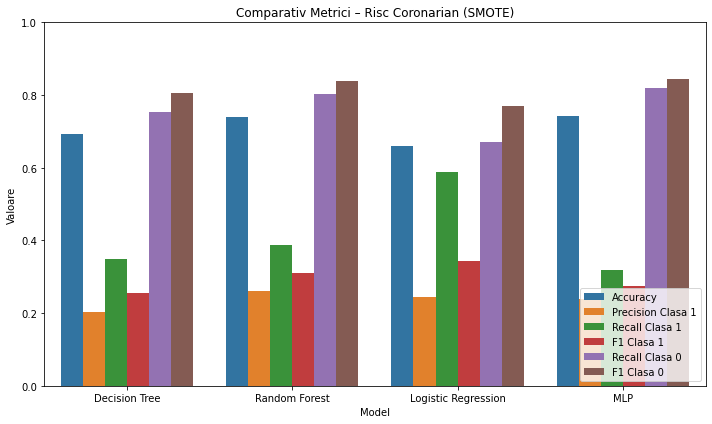

In [ ]:
from sklearn.model_selection import learning_curve
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# === 1. Aplicăm SMOTE doar pe setul de antrenament ===
print("Distribuție clase înainte de SMOTE:", np.bincount(y_train))
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)
print("Distribuție clase după SMOTE:", np.bincount(y_train_bal))

# === 2. Funcție de evaluare ===
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)

    print(f"\n=== {name} ===")
    print(f"Acuratețe: {acc:.3f}")
    print("Classification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matrice Confuzie – {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# === 3. Modele ML ===

# 3.1 Decision Tree
dt = DecisionTreeClassifier(
    max_depth=5,               # adâncime maximă a arborelui
    min_samples_leaf=10,       # minim 10 exemple per frunză
    criterion='gini',          # funcția de impuritate
    class_weight='balanced',   # ponderare automată pe clase
    random_state=42
)
evaluate_model(dt, X_train_bal, y_train_bal, X_test_prep, y_test, 'Decision Tree (SMOTE)')

# 3.2 Random Forest
rf = RandomForestClassifier(
    n_estimators=100,          # număr arbori
    max_depth=7,
    min_samples_leaf=5,
    max_features='sqrt',       # proporția de atribute per arbore
    criterion='gini',
    class_weight='balanced',
    random_state=42
)
evaluate_model(rf, X_train_bal, y_train_bal, X_test_prep, y_test, 'Random Forest (SMOTE)')

# 3.3 Logistic Regression
lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    tol =1e-6,
    class_weight='balanced',
    random_state=42
)
evaluate_model(lr, X_train_bal, y_train_bal, X_test_prep, y_test, 'Logistic Regression (SMOTE)')

# 3.4 MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=False,
    random_state=42
)
evaluate_model(mlp, X_train_bal, y_train_bal, X_test_prep, y_test, 'MLP (SMOTE)')

# === 4. Learning Curves pentru MLP ===
train_sizes, train_scores, val_scores = learning_curve(
    mlp, X_train_bal, y_train_bal,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
)
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train Accuracy')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation Accuracy')
plt.xlabel('Număr exemple de antrenament')
plt.ylabel('Acuratețe')
plt.title('Learning Curves - MLP (SMOTE)')
plt.legend()
plt.grid(True)
plt.show()

# === 5. Tabel comparativ ===
results = []
for name, model in [('Decision Tree', dt), ('Random Forest', rf), ('Logistic Regression', lr), ('MLP', mlp)]:
    y_pred = model.predict(X_test_prep)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision Clasa 1': report['1']['precision'],
        'Recall Clasa 1': report['1']['recall'],
        'F1 Clasa 1': report['1']['f1-score'],
        'Recall Clasa 0': report['0']['recall'],
        'F1 Clasa 0': report['0']['f1-score']
    })

results_df = pd.DataFrame(results)
print("\n=== Tabel comparativ – Risc Coronarian ===")
print(results_df.round(3))

# === 6. Vizualizare barplot ===
melt_df = results_df.melt(id_vars='Model', var_name='Metrică', value_name='Valoare')

plt.figure(figsize=(10,6))
sns.barplot(data=melt_df, x='Model', y='Valoare', hue='Metrică')
plt.ylim(0,1)
plt.title('Comparativ Metrici – Risc Coronarian (SMOTE)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()




## Concluze:


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 4. Performanța modelelor – tabel sumar ===
summary_data = {
    "Model": ["Random Forest", "Logistic Regression", "MLP", "Decision Tree"],
    "Set": ["Ambele", "PIR", "Risc Coronarian", "Ambele"],
    "Cea mai bună metrică": [
        "Acuratețe generală și stabilitate bună",
        "Recall foarte bun pentru clasa 1",
        "F1 ridicat după echilibrare cu SMOTE",
        "Performanță decentă, dar sub celelalte"
    ]
}

summary_df = pd.DataFrame(summary_data)

# Afișează tabelul frumos
from IPython.display import display
print("=== 4. Performanța modelelor ===")
display(summary_df)


=== 4. Performanța modelelor ===


,Model,Set,Cea mai bună metrică
0,Random Forest,Ambele,Acuratețe generală și stabilitate bună
1,Logistic Regression,PIR,Recall foarte bun pentru clasa 1
2,MLP,Risc Coronarian,F1 ridicat după echilibrare cu SMOTE
3,Decision Tree,Ambele,"Performanță decentă, dar sub celelalte"
